# DermMel Dataset Exploration

このノートブックでは、DermMelデータセット（皮膚病変画像）の内容を確認します。

In [1]:
import os
import random
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

# データセットのパス
DATA_DIR = '/mnt/data1/Public/MedImages/DermMel'
TRAIN_IMG_DIR = os.path.join(DATA_DIR, 'train_sep')

In [2]:
# データセット構造の確認
if os.path.exists(TRAIN_IMG_DIR):
    print(f"データディレクトリ: {TRAIN_IMG_DIR}")
    subdirs = [d for d in os.listdir(TRAIN_IMG_DIR) if os.path.isdir(os.path.join(TRAIN_IMG_DIR, d))]
    print(f"\nクラスフォルダ: {subdirs}")
    
    # 各クラスの画像数を確認
    for subdir in subdirs:
        class_path = os.path.join(TRAIN_IMG_DIR, subdir)
        images = list(Path(class_path).glob('**/*.jpg')) + list(Path(class_path).glob('**/*.jpeg')) + \
                 list(Path(class_path).glob('**/*.png')) + list(Path(class_path).glob('**/*.tif')) + \
                 list(Path(class_path).glob('**/*.tiff')) + list(Path(class_path).glob('**/*.bmp'))
        print(f"  {subdir}: {len(images)} 画像")
else:
    print(f"ディレクトリが見つかりません: {TRAIN_IMG_DIR}")

データディレクトリ: /mnt/data1/Public/MedImages/DermMel/train_sep

クラスフォルダ: ['NotMelanoma', 'Melanoma']
  NotMelanoma: 5341 画像
  Melanoma: 5341 画像


In [3]:
# 画像パスを再帰的に収集
image_paths = []
extensions = ("jpg", "jpeg", "png", "tif", "tiff", "bmp", "webp")
root_path = Path(TRAIN_IMG_DIR)

for ext in extensions:
    for p in root_path.glob(f"**/*.{ext}"):
        if p.is_file():
            image_paths.append(str(p))

print(f"合計画像数: {len(image_paths)}")

# ランダムに16枚選択
if len(image_paths) >= 16:
    sample_paths = random.sample(image_paths, 16)
else:
    sample_paths = image_paths[:16]
    print(f"警告: 画像が16枚未満です ({len(image_paths)}枚)")

合計画像数: 10682


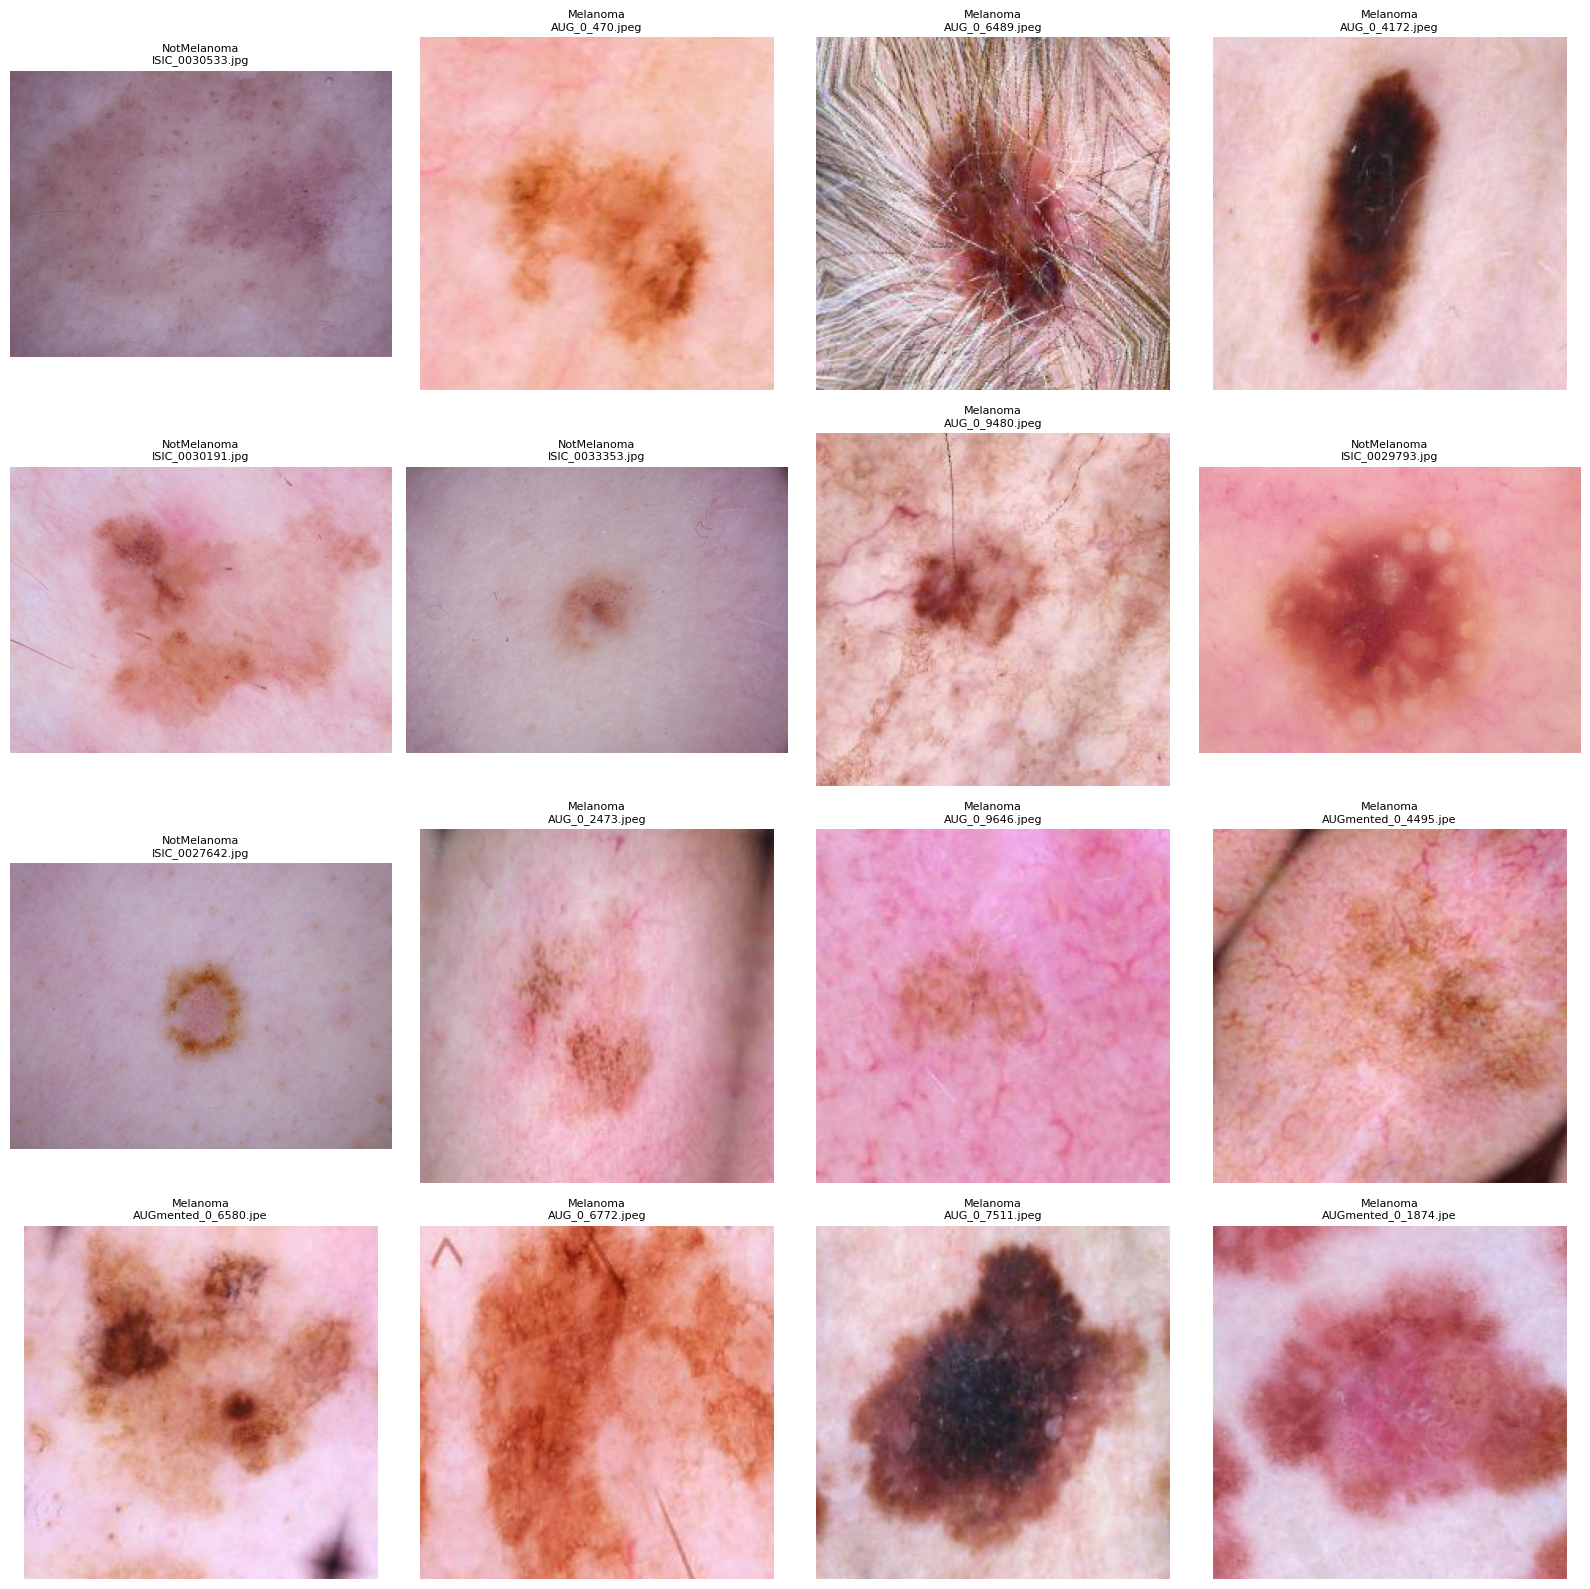


表示した画像サンプル:
1. NotMelanoma/ISIC_0030533.jpg
2. Melanoma/AUG_0_470.jpeg
3. Melanoma/AUG_0_6489.jpeg
4. Melanoma/AUG_0_4172.jpeg
5. NotMelanoma/ISIC_0030191.jpg
6. NotMelanoma/ISIC_0033353.jpg
7. Melanoma/AUG_0_9480.jpeg
8. NotMelanoma/ISIC_0029793.jpg
9. NotMelanoma/ISIC_0027642.jpg
10. Melanoma/AUG_0_2473.jpeg
11. Melanoma/AUG_0_9646.jpeg
12. Melanoma/AUGmented_0_4495.jpeg
13. Melanoma/AUGmented_0_6580.jpeg
14. Melanoma/AUG_0_6772.jpeg
15. Melanoma/AUG_0_7511.jpeg
16. Melanoma/AUGmented_0_1874.jpeg


In [4]:
# 16枚の画像を4x4グリッドで表示
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()

for idx, img_path in enumerate(sample_paths):
    try:
        img = Image.open(img_path).convert('RGB')
        axes[idx].imshow(img)
        
        # ファイル名とクラス名を表示
        filename = Path(img_path).name
        parent_dir = Path(img_path).parent.name
        axes[idx].set_title(f"{parent_dir}\n{filename[:20]}", fontsize=8)
        axes[idx].axis('off')
    except Exception as e:
        axes[idx].text(0.5, 0.5, f"Error: {e}", ha='center', va='center')
        axes[idx].axis('off')

plt.tight_layout()
plt.show()

print(f"\n表示した画像サンプル:")
for i, path in enumerate(sample_paths, 1):
    print(f"{i}. {Path(path).parent.name}/{Path(path).name}")

In [5]:
# 画像サイズの分布を確認
print("サンプル画像のサイズ:")
sizes = []
for img_path in sample_paths[:5]:  # 最初の5枚だけチェック
    try:
        img = Image.open(img_path)
        print(f"  {Path(img_path).name}: {img.size} (width x height)")
        sizes.append(img.size)
    except Exception as e:
        print(f"  Error loading {img_path}: {e}")

サンプル画像のサイズ:
  ISIC_0030533.jpg: (600, 450) (width x height)
  AUG_0_470.jpeg: (224, 224) (width x height)
  AUG_0_6489.jpeg: (224, 224) (width x height)
  AUG_0_4172.jpeg: (224, 224) (width x height)
  ISIC_0030191.jpg: (600, 450) (width x height)


In [ ]:
# リサイズ画像の表示（224x224）

拡散モデルの学習・生成サイズに合わせて、元画像を224x224にリサイズした状態を確認します。

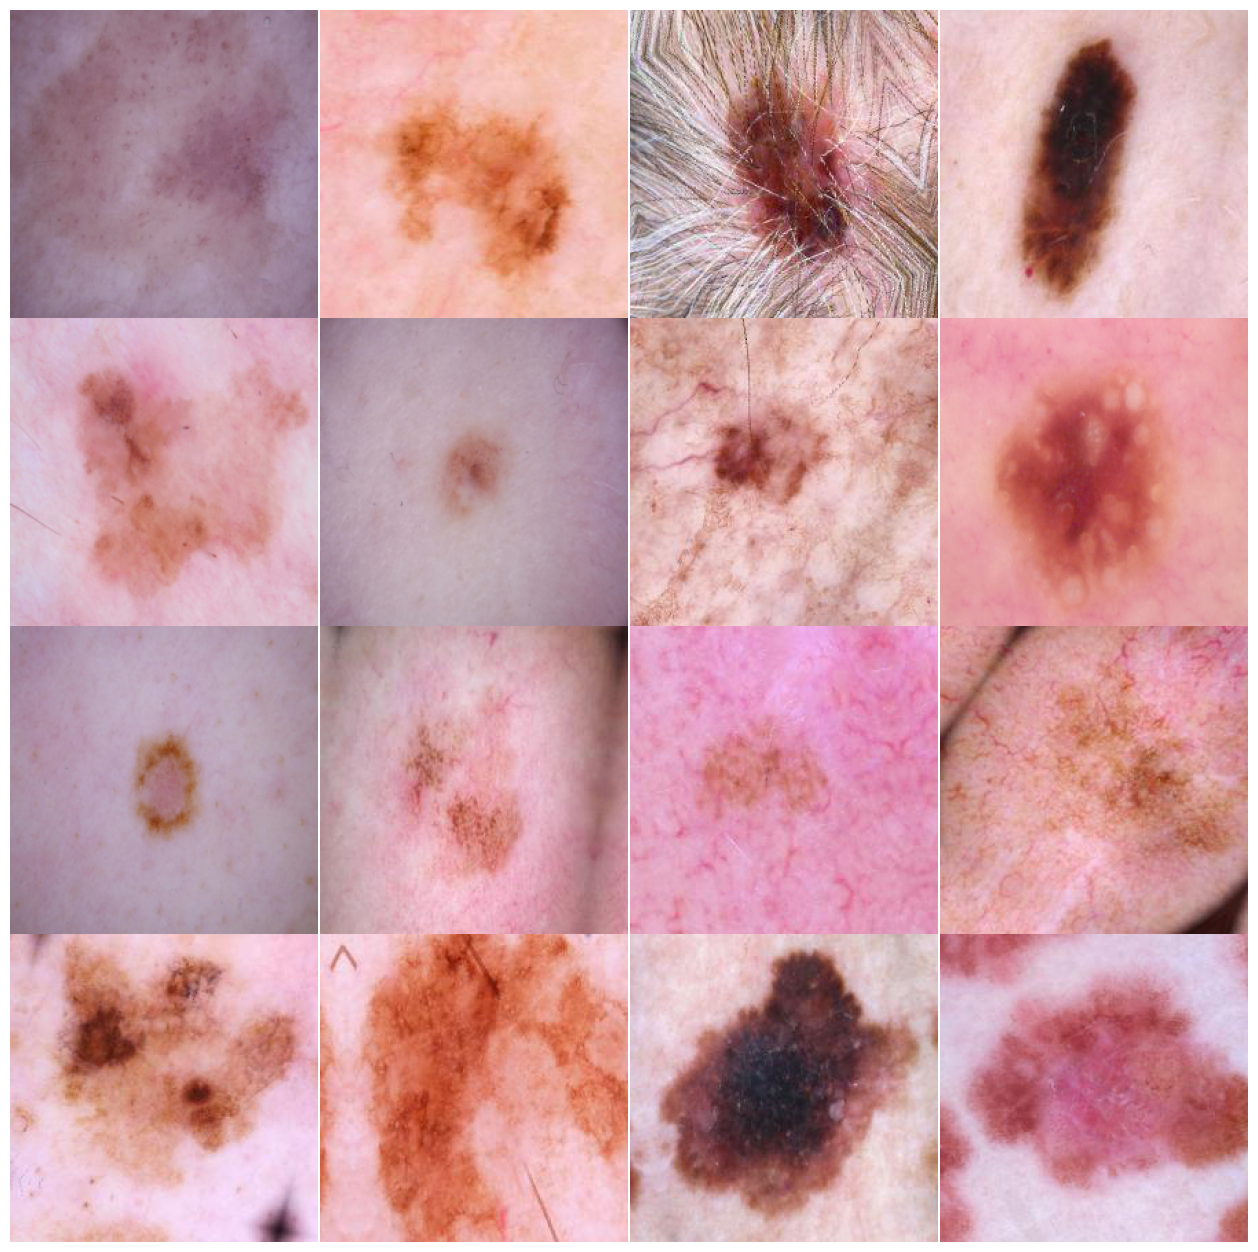


リサイズ後のサイズ: 224x224
表示画像数: 16


In [10]:
from torchvision import transforms

# リサイズ用のtransform（拡散モデルと同じ224x224）
resize_transform = transforms.Compose([
    transforms.Resize((224, 224)),
])

# 16枚の画像を224x224にリサイズして4x4グリッドで表示
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()

for idx, img_path in enumerate(sample_paths):
    try:
        img = Image.open(img_path).convert('RGB')
        img_resized = resize_transform(img)
        axes[idx].imshow(img_resized)
        
        # ファイル名とクラス名を表示
        axes[idx].axis('off')
    except Exception as e:
        axes[idx].text(0.5, 0.5, f"Error: {e}", ha='center', va='center')
        axes[idx].axis('off')

# 画像間の余白を0に設定
plt.subplots_adjust(wspace=0, hspace=0)
plt.show()

print(f"\nリサイズ後のサイズ: 224x224")
print(f"表示画像数: {len(sample_paths)}")

## 拡散モデル生成サンプルとの比較

上記のリサイズ画像は、DDPMが学習・生成する際のサイズ（224x224）です。
生成された画像と元画像（リサイズ後）を比較することで、拡散モデルの品質を視覚的に評価できます。

生成画像の確認は `ddpm/ddpm_out/samples_epoch*.png` を参照してください。